In [1]:
import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) =\
keras.datasets.fashion_mnist.load_data()
train_scaled = train_input/255
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, random_state=42, test_size=0.2)

In [2]:
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28,28)))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu'))
    # if 구문으로 model_fn 함수에 (a_layer 매개변수로) 케라스 층을 추가하면 은닉층 뒤에 또 하나의 층 추가
    if a_layer:
        model.add(a_layer)
    model.add(keras.layers.Dense(10, activation='softmax'))
    return model

In [3]:
model = model_fn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=10, verbose=0)


In [5]:
print(history.history)

{'accuracy': [0.8109583258628845, 0.8570833206176758, 0.8711041808128357, 0.879604160785675, 0.8855000138282776, 0.89041668176651, 0.8932291865348816, 0.8986250162124634, 0.8998125195503235, 0.9031875133514404], 'loss': [0.5348950028419495, 0.3948283791542053, 0.35636454820632935, 0.3313116431236267, 0.31604719161987305, 0.304887056350708, 0.2940196096897125, 0.28736162185668945, 0.2791212499141693, 0.2716000974178314]}


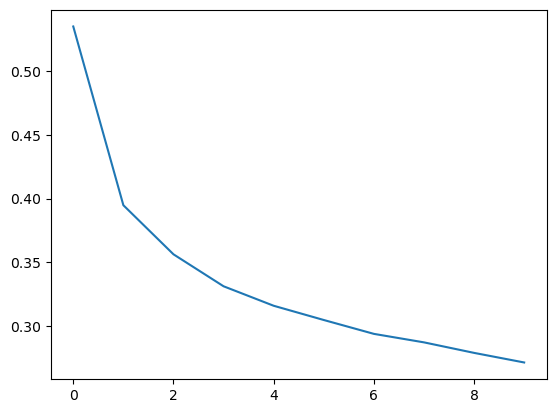

In [6]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])


In [7]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8127 - loss: 0.5345 - val_accuracy: 0.8562 - val_loss: 0.4155
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8575 - loss: 0.3930 - val_accuracy: 0.8587 - val_loss: 0.3931
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8717 - loss: 0.3533 - val_accuracy: 0.8676 - val_loss: 0.3720
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8802 - loss: 0.3342 - val_accuracy: 0.8774 - val_loss: 0.3495
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8853 - loss: 0.3178 - val_accuracy: 0.8771 - val_loss: 0.3481
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8901 - loss: 0.3051 - val_accuracy: 0.8737 - val_loss: 0.3654
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8944 - loss: 0.2955 - val_accuracy: 0.8772 - val_loss: 0.3702
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8969 - loss: 0.2877 - 

In [8]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


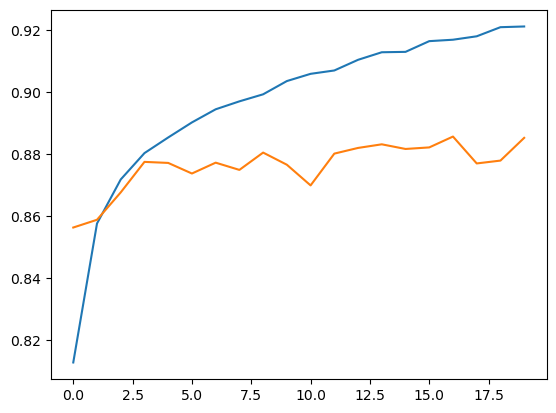

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

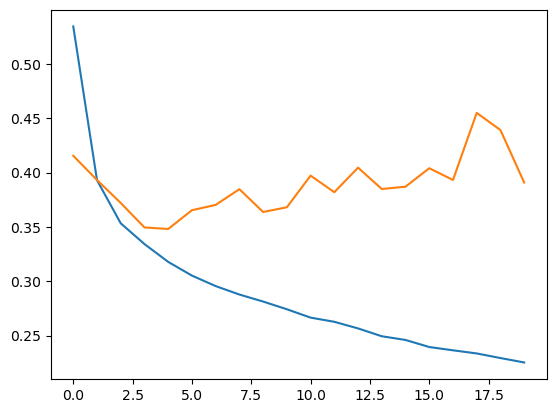

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

Text(0.5, 1.0, 'Accuracy')

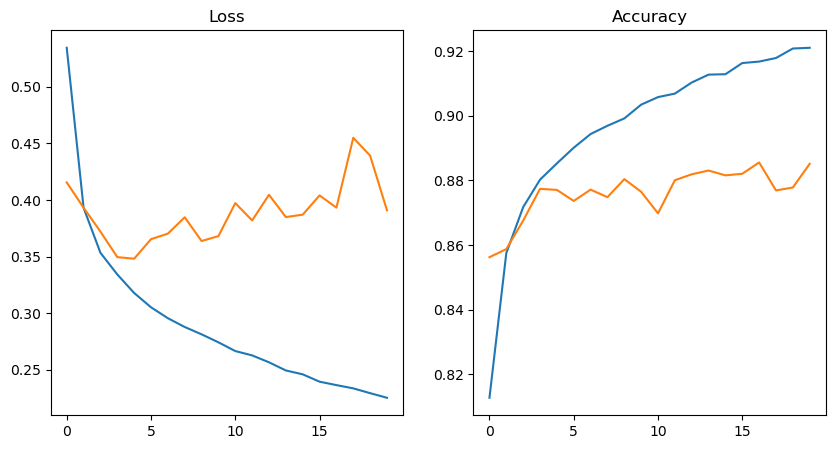

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(history.history['loss'])
axs[0].plot(history.history['val_loss'])
axs[1].plot(history.history['accuracy'])
axs[1].plot(history.history['val_accuracy'])
axs[0].set_title('Loss')
axs[1].set_title('Accuracy')

In [12]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=11, verbose=0, validation_data=(val_scaled, val_target))

In [13]:
model.save('model-whole.keras')

In [14]:
model = model_fn(keras.layers.Dropout(0.3))
model.load_weights('model-whole.keras')

In [15]:
import numpy as np

val_labels = np.argmax(model.predict(val_scaled), axis=-1)
print(np.mean(val_labels == val_target))

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
0.88275


In [17]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7918 - loss: 0.5875 - val_accuracy: 0.8507 - val_loss: 0.4205
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8416 - loss: 0.4437 - val_accuracy: 0.8625 - val_loss: 0.3807
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8532 - loss: 0.4062 - val_accuracy: 0.8602 - val_loss: 0.3791
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8589 - loss: 0.3833 - val_accuracy: 0.8746 - val_loss: 0.3516
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8672 - loss: 0.3646 - val_accuracy: 0.8684 - val_loss: 0.3596
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8707 - loss: 0.3538 - val_accuracy: 0.8763 - val_loss: 0.3379
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8736 - loss: 0.3425 - val_accuracy: 0.8763 - val_loss: 0.3324
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8772 - loss: 0.3321 - 